# Euclid subset exploration and reconstruction setup

En este notebook vamos a:

1. inspeccionar el subset compacto (`top20` o `top50`)
2. visualizar ejemplos aleatorios
3. revisar la distribución del score de detectabilidad `Δχ²`
4. preparar los tensores para entrenamiento
5. hacer el split train / val / test
6. dejar listo el dataset para el reconstructor

En esta versión usamos `Δχ²` como score principal de detectabilidad, no `ΔBIC`.

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotx

import torch
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr

plt.style.use(matplotx.styles.dracula)

In [2]:
# ======================
# Paths / parameters
# ======================
SUBSET_H5 = "/home/kingsman/Escritorio/PhD/Main/Lenstronomy/euclid/data/subsets/euclid_top20_pred.h5"
# SUBSET_H5 = "/home/kingsman/Escritorio/PhD/Main/Lenstronomy/euclid/data/subsets/euclid_top50_pred.h5"

N_EXAMPLES = 4
RANDOM_SEED = 42
TRAIN_SEED = 42

In [3]:
def _safe_log10(x, lo=1e-12):
    x = np.asarray(x, float)
    return np.log10(np.clip(x, lo, None))

def _stats(name, a):
    a = np.asarray(a, float)
    a = a[np.isfinite(a)]
    if a.size == 0:
        print(f"[{name}] empty")
        return
    print(
        f"[{name}] N={a.size} | "
        f"mean={np.mean(a):.3g} | std={np.std(a):.3g} | "
        f"median={np.median(a):.3g} | "
        f"p16={np.percentile(a,16):.3g} | p84={np.percentile(a,84):.3g} | "
        f"min={a.min():.3g} | max={a.max():.3g}"
    )

def _clean(a):
    a = np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0)
    a = a.astype("float32", copy=False)
    return np.ascontiguousarray(a)

## 1. Inspección del archivo HDF5

Primero revisamos qué datasets contiene el archivo compacto y confirmamos sus shapes.

In [4]:
with h5py.File(SUBSET_H5, "r") as f:
    print("Keys:")
    for k in f.keys():
        print(f" - {k}: shape={f[k].shape}, dtype={f[k].dtype}")

Keys:
 - dchi2: shape=(10000,), dtype=float64
 - delta_psi: shape=(10000, 64, 64), dtype=float32
 - image_nosub_nonoise: shape=(10000, 64, 64), dtype=float32
 - image_obs: shape=(10000, 64, 64), dtype=float32
 - index_map: shape=(10000, 2), dtype=int64
 - subhalo_mass: shape=(10000,), dtype=float64
 - subhalo_x: shape=(10000,), dtype=float32
 - subhalo_y: shape=(10000,), dtype=float32


## 2. Carga básica y score de detectabilidad

Aquí cargamos las imágenes, los targets físicos y el score `Δχ²`.

In [5]:
with h5py.File(SUBSET_H5, "r") as f:
    # inputs / targets
    X_noisy = f["image_obs"][:]
    Y_clean = f["image_nosub_nonoise"][:]
    Y_delta = f["delta_psi"][:]

    # subhalo scalars
    sub_mass = f["subhalo_mass"][:]
    sub_x    = f["subhalo_x"][:]
    sub_y    = f["subhalo_y"][:]

    # detectability score
    if "dchi2" in f:
        dchi2 = f["dchi2"][:]
    elif ("chi2_sub" in f) and ("chi2_nosub" in f):
        dchi2 = f["chi2_nosub"][:] - f["chi2_sub"][:]
    else:
        raise KeyError("No se encontró 'dchi2' ni ('chi2_sub','chi2_nosub') en el archivo.")

print("Loaded:")
print("X_noisy :", X_noisy.shape)
print("Y_clean :", Y_clean.shape)
print("Y_delta :", Y_delta.shape)
print("sub_mass:", sub_mass.shape)
print("dchi2   :", dchi2.shape)

Loaded:
X_noisy : (10000, 64, 64)
Y_clean : (10000, 64, 64)
Y_delta : (10000, 64, 64)
sub_mass: (10000,)
dchi2   : (10000,)


## 3. Estadísticas globales del subset

Revisamos la distribución de masa, posición y `Δχ²`.

=== Global stats ===
[subhalo_mass] N=10000 | mean=4.93e+08 | std=2.56e+08 | median=4.68e+08 | p16=2.11e+08 | p84=7.98e+08 | min=2.9e+07 | max=1e+09
[subhalo_x] N=10000 | mean=-0.000717 | std=0.921 | median=0.00455 | p16=-1.08 | p84=1.08 | min=-1.6 | max=1.6
[subhalo_y] N=10000 | mean=-0.00104 | std=0.918 | median=0.00352 | p16=-1.09 | p84=1.08 | min=-1.6 | max=1.6
[dchi2] N=10000 | mean=848 | std=661 | median=652 | p16=351 | p84=1.29e+03 | min=92.3 | max=5.61e+03


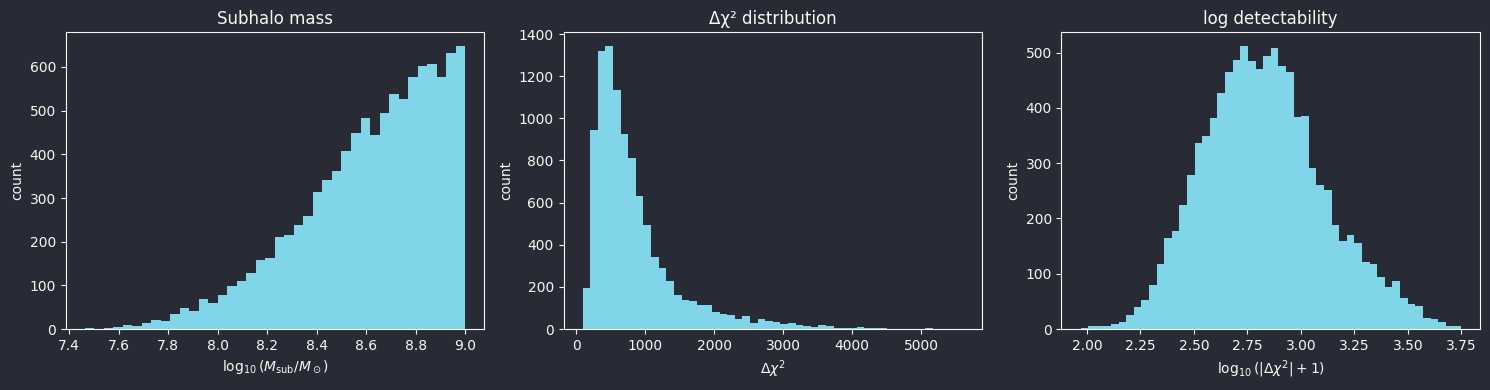

In [6]:
print("=== Global stats ===")
_stats("subhalo_mass", sub_mass)
_stats("subhalo_x", sub_x)
_stats("subhalo_y", sub_y)
_stats("dchi2", dchi2)

#------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(_safe_log10(sub_mass), bins=40, alpha=0.9)
axes[0].set_xlabel(r'$\log_{10}(M_{\rm sub}/M_\odot)$')
axes[0].set_ylabel("count")
axes[0].set_title("Subhalo mass")

axes[1].hist(dchi2, bins=50, alpha=0.9)
axes[1].set_xlabel(r'$\Delta \chi^2$')
axes[1].set_ylabel("count")
axes[1].set_title("Δχ² distribution")

axes[2].hist(_safe_log10(np.abs(dchi2) + 1.0), bins=50, alpha=0.9)
axes[2].set_xlabel(r'$\log_{10}(|\Delta \chi^2| + 1)$')
axes[2].set_ylabel("count")
axes[2].set_title("log detectability")

plt.tight_layout()
plt.show()

## 4. Ejemplos aleatorios

Mostramos algunos sistemas con:

- imagen observada
- imagen sin subhalo
- residual
- mapa de `Δψ`
- métricas básicas del sistema

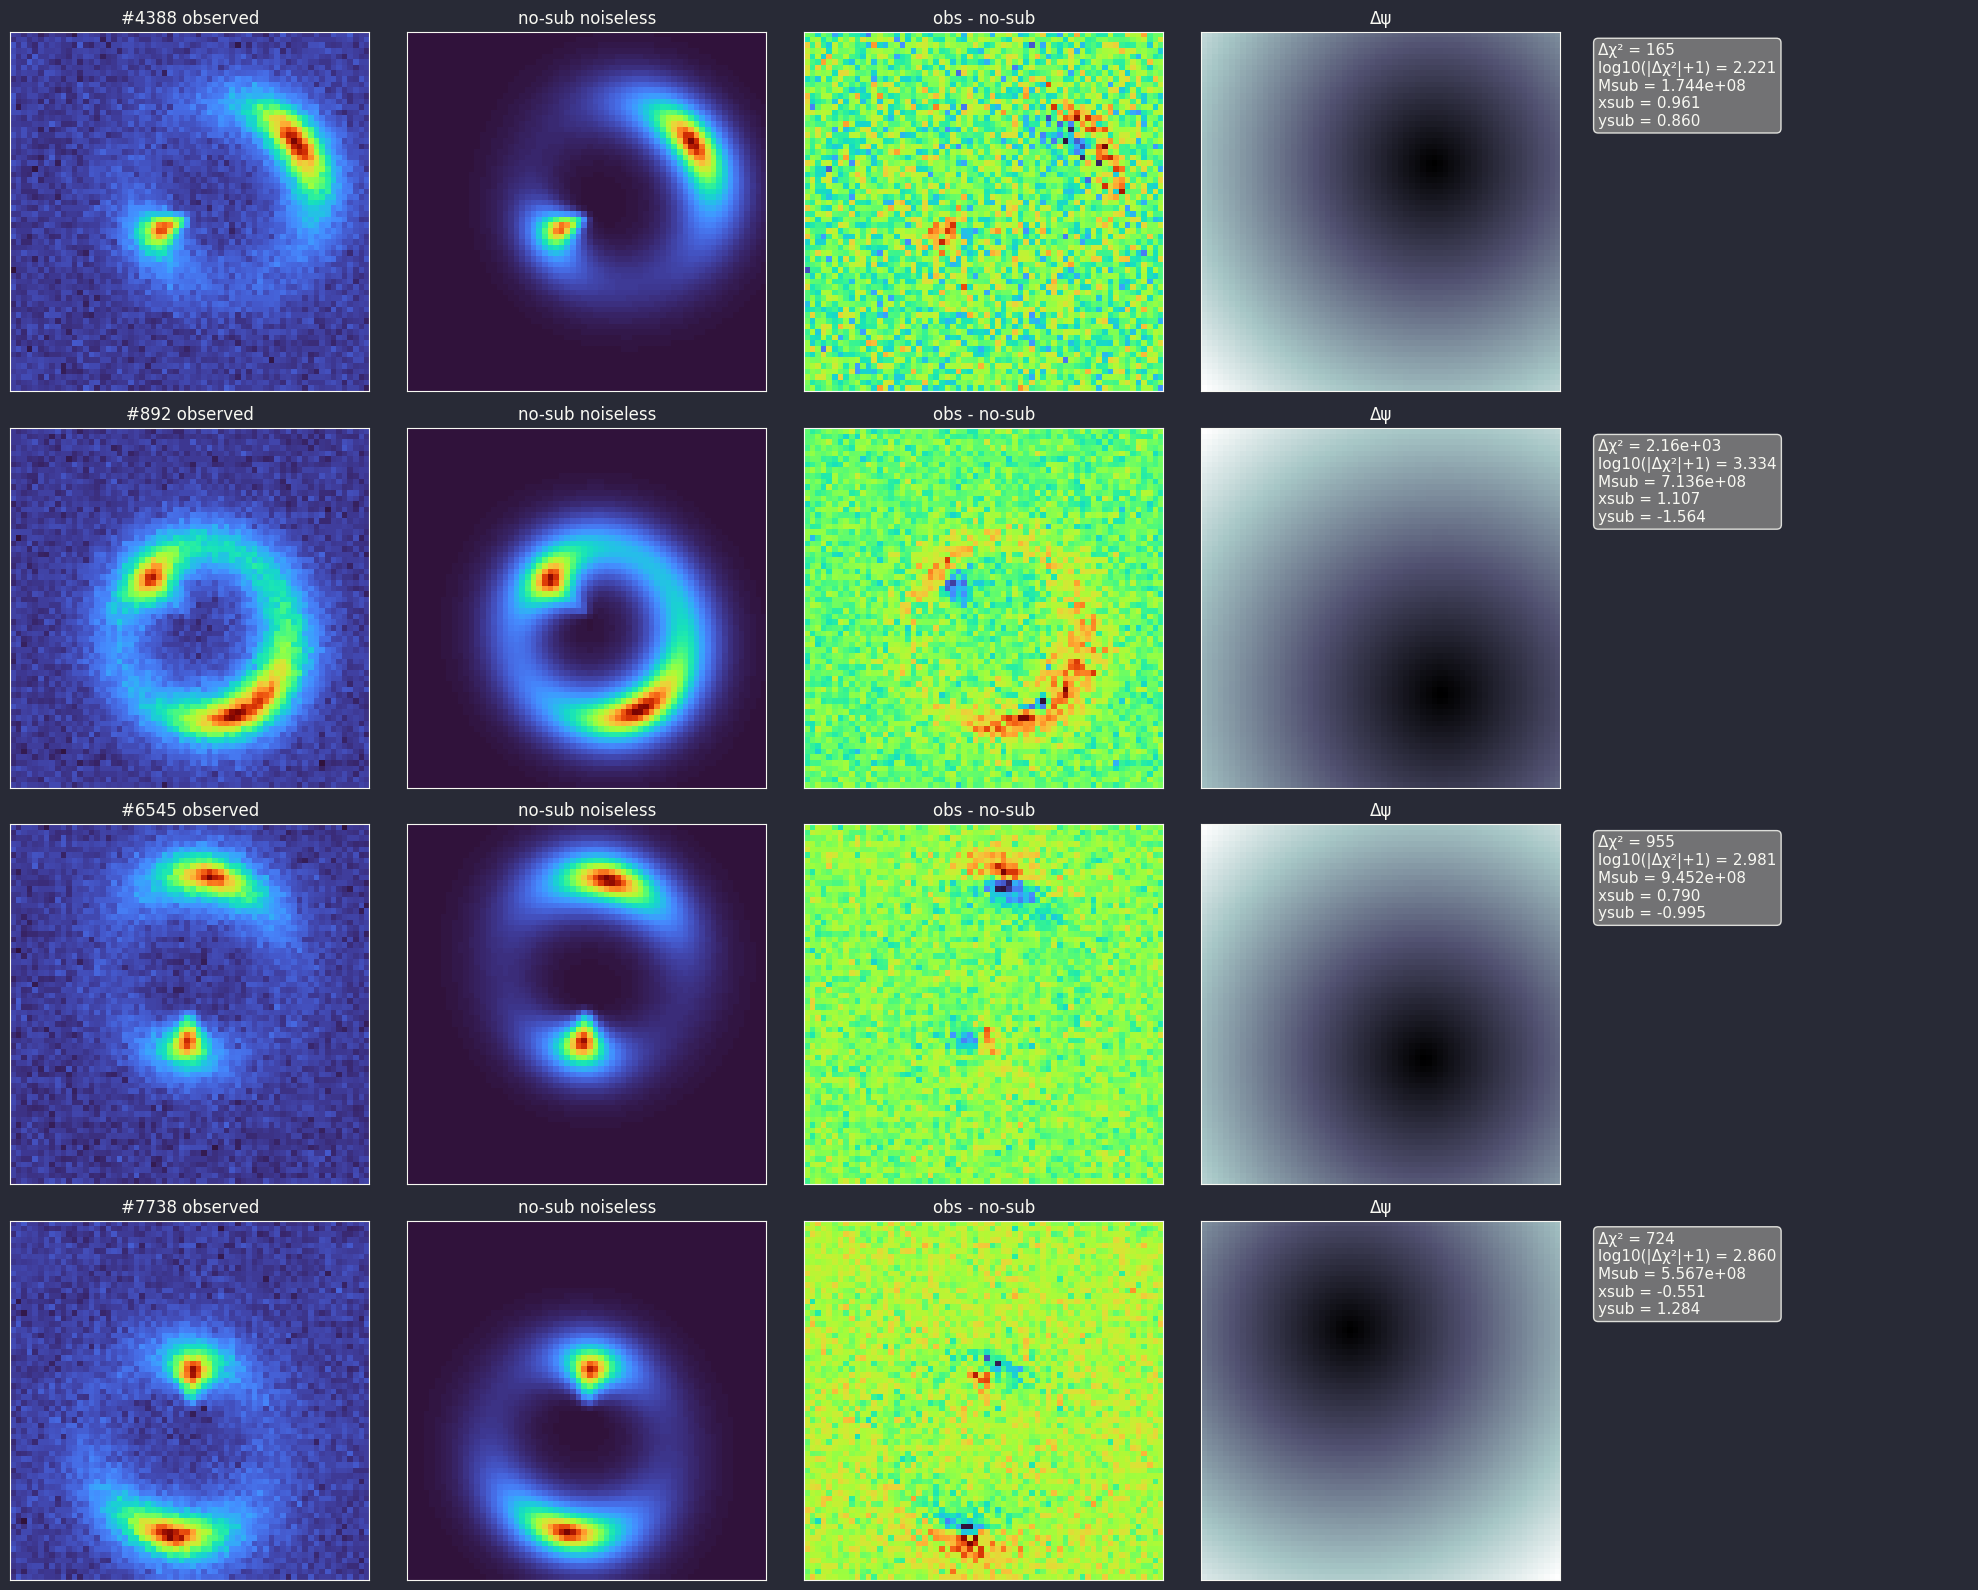

In [7]:
rng = np.random.default_rng(RANDOM_SEED)
N = X_noisy.shape[0]
idxs = rng.choice(N, size=min(N_EXAMPLES, N), replace=False)

fig, axes = plt.subplots(len(idxs), 5, figsize=(20, 4 * len(idxs)))
if len(idxs) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, idx in enumerate(idxs):
    obs   = X_noisy[idx]
    clean = Y_clean[idx]
    dpsi  = Y_delta[idx]
    resid = obs - clean

    # observed
    ax = axes[row, 0]
    ax.imshow(obs, origin="lower", cmap="turbo")
    ax.set_title(f"#{idx} observed")
    ax.set_xticks([]); ax.set_yticks([])

    # clean
    ax = axes[row, 1]
    ax.imshow(clean, origin="lower", cmap="turbo")
    ax.set_title("no-sub noiseless")
    ax.set_xticks([]); ax.set_yticks([])

    # residual
    ax = axes[row, 2]
    im = ax.imshow(resid, origin="lower", cmap="turbo")
    ax.set_title("obs - no-sub")
    ax.set_xticks([]); ax.set_yticks([])

    # delta psi
    ax = axes[row, 3]
    ax.imshow(dpsi, origin="lower", cmap="bone")
    ax.set_title("Δψ")
    ax.set_xticks([]); ax.set_yticks([])

    # text panel
    ax = axes[row, 4]
    ax.axis("off")
    txt = [
        f"Δχ² = {dchi2[idx]:.3g}",
        f"log10(|Δχ²|+1) = {_safe_log10(abs(dchi2[idx]) + 1.0):.3f}",
        f"Msub = {sub_mass[idx]:.3e}",
        f"xsub = {sub_x[idx]:.3f}",
        f"ysub = {sub_y[idx]:.3f}",
    ]
    ax.text(
        0.03, 0.97, "\n".join(txt),
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=11,
        bbox=dict(boxstyle="round", fc="grey", alpha=0.85)
    )

plt.tight_layout()
plt.show()

## 5. Relaciones simples con `Δχ²`

Exploramos si la detectabilidad se relaciona con:

- la masa del subhalo
- la posición del subhalo en el plano

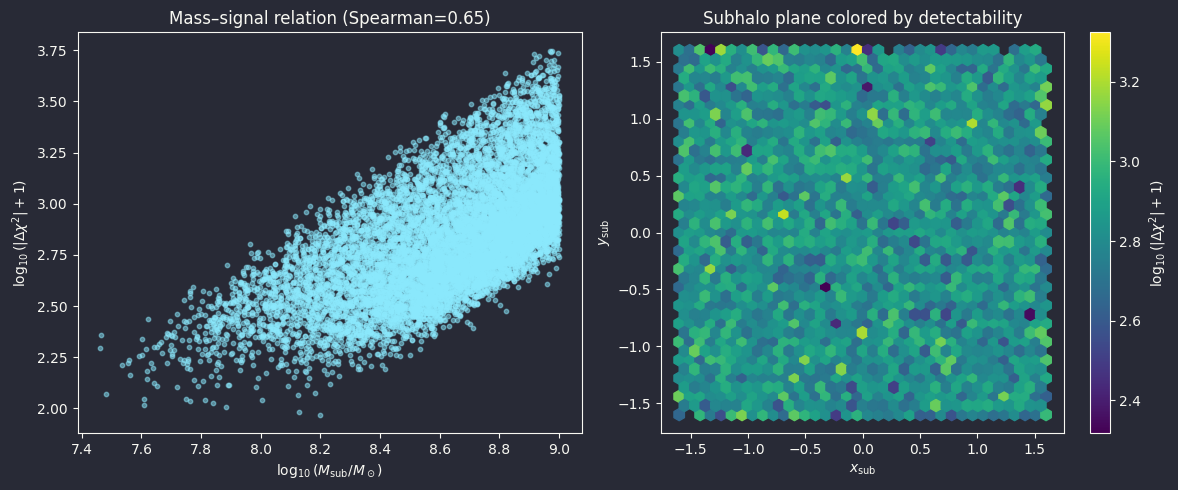

In [8]:
logM   = _safe_log10(sub_mass)
logSig = _safe_log10(np.abs(dchi2) + 1.0)

rhoM, _ = spearmanr(logM, logSig)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(logM, logSig, s=10, alpha=0.5)
axes[0].set_xlabel(r'$\log_{10}(M_{\rm sub}/M_\odot)$')
axes[0].set_ylabel(r'$\log_{10}(|\Delta \chi^2| + 1)$')
axes[0].set_title(f"Mass–signal relation (Spearman={rhoM:.2f})")

hb = axes[1].hexbin(sub_x, sub_y, C=logSig, gridsize=35, cmap="viridis")
axes[1].set_xlabel(r'$x_{\rm sub}$')
axes[1].set_ylabel(r'$y_{\rm sub}$')
axes[1].set_title("Subhalo plane colored by detectability")
cb = plt.colorbar(hb, ax=axes[1])
cb.set_label(r'$\log_{10}(|\Delta \chi^2| + 1)$')

plt.tight_layout()
plt.show()

## 6. Preparación para entrenamiento

Ahora limpiamos arrays, convertimos a tensores y agregamos el canal para PyTorch.

In [9]:
X_noisy  = _clean(X_noisy)
Y_clean  = _clean(Y_clean)
Y_delta  = _clean(Y_delta)

sub_mass = _clean(sub_mass)
sub_x    = _clean(sub_x)
sub_y    = _clean(sub_y)
dchi2    = _clean(dchi2)

X  = torch.from_numpy(X_noisy).unsqueeze(1).contiguous()
Y1 = torch.from_numpy(Y_clean).unsqueeze(1).contiguous()
Y2 = torch.from_numpy(Y_delta).unsqueeze(1).contiguous()

print("Torch tensors:")
print("X :", X.shape)
print("Y1:", Y1.shape)
print("Y2:", Y2.shape)

Torch tensors:
X : torch.Size([10000, 1, 64, 64])
Y1: torch.Size([10000, 1, 64, 64])
Y2: torch.Size([10000, 1, 64, 64])


## 7. Split train / val / test

Usamos un split aleatorio 70 / 20 / 10.

In [10]:
np.random.seed(TRAIN_SEED)
torch.manual_seed(TRAIN_SEED)

N = X.shape[0]
idx_all = np.arange(N)

idx_rest, idx_test = train_test_split(
    idx_all, test_size=0.10, random_state=TRAIN_SEED, shuffle=True
)
idx_train, idx_val = train_test_split(
    idx_rest, test_size=2/9, random_state=TRAIN_SEED, shuffle=True
)

X_train, X_val, X_test    = X[idx_train],  X[idx_val],  X[idx_test]
Y1_train, Y1_val, Y1_test = Y1[idx_train], Y1[idx_val], Y1[idx_test]
Y2_train, Y2_val, Y2_test = Y2[idx_train], Y2[idx_val], Y2[idx_test]

mass_train, mass_val, mass_test = sub_mass[idx_train], sub_mass[idx_val], sub_mass[idx_test]
x_train, x_val, x_test          = sub_x[idx_train],    sub_x[idx_val],    sub_x[idx_test]
y_train, y_val, y_test          = sub_y[idx_train],    sub_y[idx_val],    sub_y[idx_test]
dchi2_train, dchi2_val, dchi2_test = dchi2[idx_train], dchi2[idx_val], dchi2[idx_test]

print("Train:", len(idx_train))
print("Val  :", len(idx_val))
print("Test :", len(idx_test))

Train: 7000
Val  : 2000
Test : 1000


## 8. Revisión rápida de los splits

Verificamos que la distribución de masa, posición y `Δχ²` sea razonable en train, val y test.

In [11]:
print("=== Train / Val / Test stats ===")
_stats("mass_train", mass_train)
_stats("mass_val", mass_val)
_stats("mass_test", mass_test)

_stats("x_train", x_train)
_stats("x_val", x_val)
_stats("x_test", x_test)

_stats("y_train", y_train)
_stats("y_val", y_val)
_stats("y_test", y_test)

_stats("dchi2_train", dchi2_train)
_stats("dchi2_val", dchi2_val)
_stats("dchi2_test", dchi2_test)

=== Train / Val / Test stats ===
[mass_train] N=7000 | mean=4.92e+08 | std=2.56e+08 | median=4.68e+08 | p16=2.11e+08 | p84=7.94e+08 | min=2.9e+07 | max=1e+09
[mass_val] N=2000 | mean=4.97e+08 | std=2.58e+08 | median=4.72e+08 | p16=2.12e+08 | p84=8.07e+08 | min=3.62e+07 | max=1e+09
[mass_test] N=1000 | mean=4.89e+08 | std=2.56e+08 | median=4.51e+08 | p16=2.09e+08 | p84=8.12e+08 | min=4.37e+07 | max=1e+09
[x_train] N=7000 | mean=0.00249 | std=0.923 | median=0.00739 | p16=-1.08 | p84=1.08 | min=-1.6 | max=1.6
[x_val] N=2000 | mean=-0.0323 | std=0.913 | median=-0.0182 | p16=-1.09 | p84=1.05 | min=-1.59 | max=1.6
[x_test] N=1000 | mean=0.0401 | std=0.923 | median=0.0335 | p16=-1.04 | p84=1.13 | min=-1.6 | max=1.6
[y_train] N=7000 | mean=0.00223 | std=0.919 | median=0.00477 | p16=-1.08 | p84=1.08 | min=-1.6 | max=1.6
[y_val] N=2000 | mean=-0.00418 | std=0.925 | median=0.00881 | p16=-1.12 | p84=1.08 | min=-1.6 | max=1.6
[y_test] N=1000 | mean=-0.0177 | std=0.899 | median=-0.0108 | p16=-1.06 |

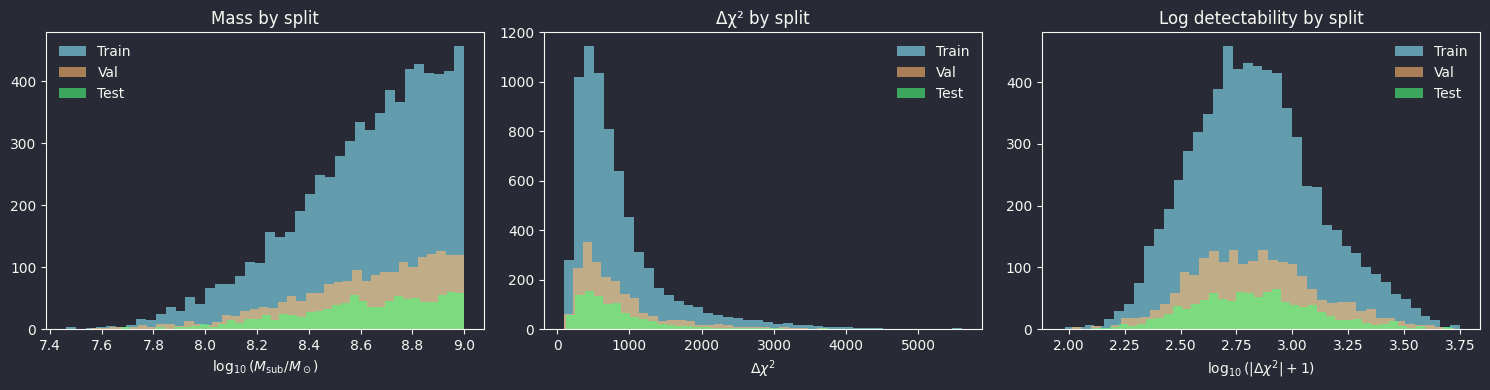

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(_safe_log10(mass_train), bins=40, alpha=0.6, label="Train")
axes[0].hist(_safe_log10(mass_val),   bins=40, alpha=0.6, label="Val")
axes[0].hist(_safe_log10(mass_test),  bins=40, alpha=0.6, label="Test")
axes[0].set_xlabel(r'$\log_{10}(M_{\rm sub}/M_\odot)$')
axes[0].set_title("Mass by split")
axes[0].legend()

axes[1].hist(dchi2_train, bins=40, alpha=0.6, label="Train")
axes[1].hist(dchi2_val,   bins=40, alpha=0.6, label="Val")
axes[1].hist(dchi2_test,  bins=40, alpha=0.6, label="Test")
axes[1].set_xlabel(r'$\Delta \chi^2$')
axes[1].set_title("Δχ² by split")
axes[1].legend()

axes[2].hist(_safe_log10(np.abs(dchi2_train)+1), bins=40, alpha=0.6, label="Train")
axes[2].hist(_safe_log10(np.abs(dchi2_val)+1),   bins=40, alpha=0.6, label="Val")
axes[2].hist(_safe_log10(np.abs(dchi2_test)+1),  bins=40, alpha=0.6, label="Test")
axes[2].set_xlabel(r'$\log_{10}(|\Delta \chi^2|+1)$')
axes[2].set_title("Log detectability by split")
axes[2].legend()

plt.tight_layout()
plt.show()

## 9. Normalización básica de `Δψ`

Calculamos media y desviación estándar sobre el split de entrenamiento para usar después en el reconstructor.

In [13]:
with torch.no_grad():
    y2_tr_np = Y2_train.cpu().numpy()
    mean_dpsi = float(y2_tr_np.mean())
    std_dpsi  = float(y2_tr_np.std())

if std_dpsi == 0:
    std_dpsi = 1.0

norm_stats = {
    "delta_psi_mean_train": mean_dpsi,
    "delta_psi_std_train": std_dpsi,
}

print(norm_stats)

{'delta_psi_mean_train': 0.08629203587770462, 'delta_psi_std_train': 0.045802079141139984}


## 10. DataLoaders y normalización

Normalizamos las imágenes usando únicamente estadísticas del split de entrenamiento.

Además, normalizamos el target escalar `(mass, x, y)` usando:

- `log10(mass)`
- estandarización con media y desviación del train

In [14]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# =========================
# 1) Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# 2) Normalize X, Y1, Y2 using TRAIN only
# =========================
eps = 1e-6

with torch.no_grad():
    x_mean = X_train.mean()
    x_std  = X_train.std().clamp_min(eps)

    y1_mean = Y1_train.mean()
    y1_std  = Y1_train.std().clamp_min(eps)

    y2_mean = Y2_train.mean()
    y2_std  = Y2_train.std().clamp_min(eps)

def _norm(t, mean, std):
    return (t - mean) / std

X_train_n = _norm(X_train, x_mean, x_std)
X_val_n   = _norm(X_val,   x_mean, x_std)
X_test_n  = _norm(X_test,  x_mean, x_std)

Y1_train_n = _norm(Y1_train, y1_mean, y1_std)
Y1_val_n   = _norm(Y1_val,   y1_mean, y1_std)
Y1_test_n  = _norm(Y1_test,  y1_mean, y1_std)

Y2_train_n = _norm(Y2_train, y2_mean, y2_std)
Y2_val_n   = _norm(Y2_val,   y2_mean, y2_std)
Y2_test_n  = _norm(Y2_test,  y2_mean, y2_std)

print(f"[X_train_n] mean={float(X_train_n.mean()):.3f}, std={float(X_train_n.std()):.3f}")
print(f"[Y1_train_n] mean={float(Y1_train_n.mean()):.3f}, std={float(Y1_train_n.std()):.3f}")
print(f"[Y2_train_n] mean={float(Y2_train_n.mean()):.3f}, std={float(Y2_train_n.std()):.3f}")

# =========================
# 3) Normalize scalar targets (log10(mass), x, y) using TRAIN only
# =========================
mass_train_t = torch.from_numpy(mass_train).float()
mass_val_t   = torch.from_numpy(mass_val).float()
mass_test_t  = torch.from_numpy(mass_test).float()

x_train_t = torch.from_numpy(x_train).float()
x_val_t   = torch.from_numpy(x_val).float()
x_test_t  = torch.from_numpy(x_test).float()

y_train_t = torch.from_numpy(y_train).float()
y_val_t   = torch.from_numpy(y_val).float()
y_test_t  = torch.from_numpy(y_test).float()

mxy_train_raw = torch.stack([
    torch.log10(mass_train_t.clamp_min(1e-12)),
    x_train_t,
    y_train_t
], dim=1)

mxy_val_raw = torch.stack([
    torch.log10(mass_val_t.clamp_min(1e-12)),
    x_val_t,
    y_val_t
], dim=1)

mxy_test_raw = torch.stack([
    torch.log10(mass_test_t.clamp_min(1e-12)),
    x_test_t,
    y_test_t
], dim=1)

mxy_mean = mxy_train_raw.mean(dim=0)
mxy_std  = mxy_train_raw.std(dim=0).clamp_min(1e-6)

mxy_train = (mxy_train_raw - mxy_mean) / mxy_std
mxy_val   = (mxy_val_raw   - mxy_mean) / mxy_std
mxy_test  = (mxy_test_raw  - mxy_mean) / mxy_std

print("[mxy train mean ~]", mxy_train.mean(dim=0))
print("[mxy train std  ~]", mxy_train.std(dim=0))

mxy_norm_stats = {
    "mass_log10_mean": float(mxy_mean[0]),
    "mass_log10_std":  float(mxy_std[0]),
    "x_mean":          float(mxy_mean[1]),
    "x_std":           float(mxy_std[1]),
    "y_mean":          float(mxy_mean[2]),
    "y_std":           float(mxy_std[2]),
}

image_norm_stats = {
    "x_mean":  float(x_mean),
    "x_std":   float(x_std),
    "y1_mean": float(y1_mean),
    "y1_std":  float(y1_std),
    "y2_mean": float(y2_mean),
    "y2_std":  float(y2_std),
}

# =========================
# 4) TensorDatasets + DataLoaders
# =========================
train_ds = TensorDataset(X_train_n, Y1_train_n, Y2_train_n, mxy_train)
val_ds   = TensorDataset(X_val_n,   Y1_val_n,   Y2_val_n,   mxy_val)
test_ds  = TensorDataset(X_test_n,  Y1_test_n,  Y2_test_n,  mxy_test)

batch_size = 256   # si tu PC aguanta, luego pruebas 512
on_cuda = torch.cuda.is_available()

loader_kwargs = dict(
    batch_size=batch_size,
    num_workers=0,
    pin_memory=on_cuda,
)

train_loader = DataLoader(train_ds, shuffle=True,  drop_last=True,  **loader_kwargs)
val_loader   = DataLoader(val_ds,   shuffle=False, drop_last=False, **loader_kwargs)
test_loader  = DataLoader(test_ds,  shuffle=False, drop_last=False, **loader_kwargs)

print(f"[DataLoaders ready] batch_size={batch_size}, CUDA={on_cuda}")

Using device: cuda
[X_train_n] mean=-0.000, std=1.000
[Y1_train_n] mean=-0.000, std=1.000
[Y2_train_n] mean=-0.000, std=1.000
[mxy train mean ~] tensor([ 4.6730e-07,  1.9346e-08, -1.4169e-08])
[mxy train std  ~] tensor([1.0000, 1.0000, 1.0000])
[DataLoaders ready] batch_size=256, CUDA=True


## 11. Arquitectura del reconstructor multitask

Modelo VAE convolucional para imágenes `64×64` con tres salidas:

- reconstrucción de la imagen sin subhalo
- reconstrucción de `Δψ`
- regresión de `(log10 mass, x, y)`

La arquitectura usa skips tipo U-Net y un bottleneck de `4×4`.


In [ ]:
import torch
import torch.nn as nn

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout_p=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(dropout_p) if dropout_p > 0 else nn.Identity(),
        )

    def forward(self, x):
        return self.block(x)


class DualVAE_Euclid64(nn.Module):
    """
    Input:  (B,1,64,64)

    Encoder:
        64 -> 32 -> 16 -> 8 -> 4

    Decoder:
         4 ->  8 -> 16 -> 32 -> 64

    Outputs:
        s_out   : (B,1,64,64)  reconstructed no-sub image
        d_out   : (B,1,64,64)  reconstructed delta_psi
        mxy_out : (B,3)        [log10(mass), x, y] normalized
    """
    def __init__(
        self,
        in_ch=1,
        base_ch=16,
        z_dim=128,
        H=64,
        W=64,
        use_dropout=True,
        drop_enc=0.10,
        drop_dec=0.10,
        drop_head=0.20,
    ):
        super().__init__()

        de = drop_enc if use_dropout else 0.0
        dd = drop_dec if use_dropout else 0.0
        dh = drop_head if use_dropout else 0.0

        # =========================
        # Encoder
        # =========================
        self.enc1 = ConvBlock(in_ch,        base_ch,     stride=2, dropout_p=de)  # 64 -> 32
        self.enc2 = ConvBlock(base_ch,      base_ch * 2, stride=2, dropout_p=de)  # 32 -> 16
        self.enc3 = ConvBlock(base_ch * 2,  base_ch * 4, stride=2, dropout_p=de)  # 16 -> 8
        self.enc4 = ConvBlock(base_ch * 4,  base_ch * 8, stride=2, dropout_p=de)  # 8 -> 4

        with torch.no_grad():
            dummy = torch.zeros(1, in_ch, H, W)
            h1 = self.enc1(dummy)
            h2 = self.enc2(h1)
            h3 = self.enc3(h2)
            h4 = self.enc4(h3)

            self._feat_shape = h4.shape[1:]   # (C,4,4)
            feat_dim = h4.view(1, -1).shape[1]

        # =========================
        # Latent
        # =========================
        self.fc_mu     = nn.Linear(feat_dim, z_dim)
        self.fc_logvar = nn.Linear(feat_dim, z_dim)
        self.fc_dec    = nn.Linear(z_dim, feat_dim)

        C1 = base_ch
        C2 = base_ch * 2
        C3 = base_ch * 4
        C4 = base_ch * 8

        # =========================
        # Decoder
        # =========================
        self.up1 = nn.ConvTranspose2d(C4, C3, kernel_size=4, stride=2, padding=1)  # 4 -> 8
        self.dec1 = ConvBlock(C3 + C3, C3, stride=1, dropout_p=dd)

        self.up2 = nn.ConvTranspose2d(C3, C2, kernel_size=4, stride=2, padding=1)  # 8 -> 16
        self.dec2 = ConvBlock(C2 + C2, C2, stride=1, dropout_p=dd)

        self.up3 = nn.ConvTranspose2d(C2, C1, kernel_size=4, stride=2, padding=1)  # 16 -> 32
        self.dec3 = ConvBlock(C1 + C1, C1, stride=1, dropout_p=dd)

        self.up4 = nn.ConvTranspose2d(C1, C1, kernel_size=4, stride=2, padding=1)  # 32 -> 64
        self.dec4 = ConvBlock(C1, C1, stride=1, dropout_p=dd)

        # image heads
        self.out_s = nn.Conv2d(C1, 1, kernel_size=1)
        self.out_d = nn.Conv2d(C1, 1, kernel_size=1)

        # scalar regression head
        self.fc_regs = nn.Sequential(
            nn.Linear(z_dim, z_dim // 2),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(dh),
            nn.Linear(z_dim // 2, z_dim // 4),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(dh),
            nn.Linear(z_dim // 4, 3),
        )

    def encode(self, x):
        h1 = self.enc1(x)   # (B,C1,32,32)
        h2 = self.enc2(h1)  # (B,C2,16,16)
        h3 = self.enc3(h2)  # (B,C3,8,8)
        h4 = self.enc4(h3)  # (B,C4,4,4)

        h_flat = h4.view(h4.size(0), -1)
        mu = self.fc_mu(h_flat)
        logvar = self.fc_logvar(h_flat)

        return mu, logvar, (h1, h2, h3, h4)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, skips):
        h1, h2, h3, _ = skips

        h = self.fc_dec(z).view(-1, *self._feat_shape)  # (B,C4,4,4)

        u1 = self.up1(h)                                # (B,C3,8,8)
        u1 = self.dec1(torch.cat([u1, h3], dim=1))

        u2 = self.up2(u1)                               # (B,C2,16,16)
        u2 = self.dec2(torch.cat([u2, h2], dim=1))

        u3 = self.up3(u2)                               # (B,C1,32,32)
        u3 = self.dec3(torch.cat([u3, h1], dim=1))

        u4 = self.up4(u3)                               # (B,C1,64,64)
        u4 = self.dec4(u4)

        s_out = self.out_s(u4)
        d_out = self.out_d(u4)

        return s_out, d_out

    def forward(self, x):
        mu, logvar, skips = self.encode(x)
        z = self.reparameterize(mu, logvar)
        s_out, d_out = self.decode(z, skips)
        mxy_out = self.fc_regs(mu)   # usamos mu para regresión más estable
        return s_out, d_out, mu, logvar, mxy_out

## 12. Instanciación y prueba rápida

Creamos el modelo, el optimizador y verificamos shapes con un forward pass de prueba.

In [16]:
model = DualVAE_Euclid64(
    in_ch=1,
    base_ch=32,
    z_dim=256,
    H=64,
    W=64,
    use_dropout=True,
    drop_enc=0.10,
    drop_dec=0.10,
    drop_head=0.20,
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

model.eval()
with torch.no_grad():
    x_dummy = torch.randn(4, 1, 64, 64, device=device)
    s_pred, d_pred, mu, logvar, mxy_pred = model(x_dummy)

print("Output shapes:")
print("s_pred   :", s_pred.shape)    # (4,1,64,64)
print("d_pred   :", d_pred.shape)    # (4,1,64,64)
print("mu       :", mu.shape)        # (4,z_dim)
print("logvar   :", logvar.shape)    # (4,z_dim)
print("mxy_pred :", mxy_pred.shape)  # (4,3)

Output shapes:
s_pred   : torch.Size([4, 1, 64, 64])
d_pred   : torch.Size([4, 1, 64, 64])
mu       : torch.Size([4, 256])
logvar   : torch.Size([4, 256])
mxy_pred : torch.Size([4, 3])


## 13. Función de pérdida y utilidades de entrenamiento

La pérdida total combina:

- reconstrucción de la imagen smooth
- reconstrucción de `Δψ`
- regularización KL del VAE
- regresión de `(log10 mass, x, y)`

Los pesos `alpha`, `beta` y `gamma` controlan la contribución relativa de cada término.

In [27]:
import math
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from tqdm import trange
from torch.cuda.amp import autocast, GradScaler

# ---------------------------------
# Loss
# ---------------------------------
def combined_loss(
    s_pred, s_true,
    d_pred, d_true,
    mu, logvar,
    mxy_pred, mxy_true,
    alpha=1.0,
    beta=1e-3,
    gamma=1.0,
    reduction="mean",
):
    recon_s = F.mse_loss(s_pred, s_true, reduction=reduction)
    recon_d = F.mse_loss(d_pred, d_true, reduction=reduction)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    reg = F.mse_loss(mxy_pred, mxy_true, reduction=reduction)

    w_recon_s = recon_s
    w_recon_d = alpha * recon_d
    w_kl      = beta * kl
    w_reg     = gamma * reg

    total = w_recon_s + w_recon_d + w_kl + w_reg

    comps = {
        "recon_s":   float(recon_s.detach().cpu()),
        "recon_d":   float(recon_d.detach().cpu()),
        "kl":        float(kl.detach().cpu()),
        "reg":       float(reg.detach().cpu()),
        "w_recon_s": float(w_recon_s.detach().cpu()),
        "w_recon_d": float(w_recon_d.detach().cpu()),
        "w_kl":      float(w_kl.detach().cpu()),
        "w_reg":     float(w_reg.detach().cpu()),
        "total":     float(total.detach().cpu()),
    }
    return total, comps

# ---------------------------------
# AMP scaler
# ---------------------------------
use_amp_default = torch.cuda.is_available()
scaler = GradScaler(enabled=use_amp_default)

# ---------------------------------
# Train / eval helpers
# ---------------------------------
def train_epoch(model, loader, optimizer, device, alpha=1.0, beta=1e-3, gamma=1.0, use_amp=True):
    model.train()

    keys = ["recon_s","recon_d","kl","reg","w_recon_s","w_recon_d","w_kl","w_reg","total"]
    sums = {k: 0.0 for k in keys}
    running_loss = 0.0

    for x, y_s, y_d, mxy in loader:
        x   = x.to(device, non_blocking=True)
        y_s = y_s.to(device, non_blocking=True)
        y_d = y_d.to(device, non_blocking=True)
        mxy = mxy.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=(use_amp and device.type == "cuda")):
            p_s, p_d, mu, logvar, mxy_pred = model(x)
            loss, comps = combined_loss(
                p_s, y_s, p_d, y_d, mu, logvar, mxy_pred, mxy,
                alpha=alpha, beta=beta, gamma=gamma
            )

        if use_amp and device.type == "cuda":
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        bs = x.size(0)
        running_loss += float(loss.detach().cpu()) * bs
        for k in keys:
            sums[k] += comps[k] * bs

    N = len(loader.dataset)
    avg = {k: v / max(N, 1) for k, v in sums.items()}
    return running_loss / max(N, 1), avg


@torch.no_grad()
def eval_epoch(model, loader, device, alpha=1.0, beta=1e-3, gamma=1.0, use_amp=True):
    model.eval()

    keys = ["recon_s","recon_d","kl","reg","w_recon_s","w_recon_d","w_kl","w_reg","total"]
    sums = {k: 0.0 for k in keys}
    running_loss = 0.0

    for x, y_s, y_d, mxy in loader:
        x   = x.to(device, non_blocking=True)
        y_s = y_s.to(device, non_blocking=True)
        y_d = y_d.to(device, non_blocking=True)
        mxy = mxy.to(device, non_blocking=True)

        with autocast(enabled=(use_amp and device.type == "cuda")):
            p_s, p_d, mu, logvar, mxy_pred = model(x)
            loss, comps = combined_loss(
                p_s, y_s, p_d, y_d, mu, logvar, mxy_pred, mxy,
                alpha=alpha, beta=beta, gamma=gamma
            )

        bs = x.size(0)
        running_loss += float(loss.detach().cpu()) * bs
        for k in keys:
            sums[k] += comps[k] * bs

    N = len(loader.dataset)
    avg = {k: v / max(N, 1) for k, v in sums.items()}
    return running_loss / max(N, 1), avg


def print_loss_balance(comps, eps=1e-12):
    tot = comps["w_recon_s"] + comps["w_recon_d"] + comps["w_kl"] + comps["w_reg"] + eps
    print("Weighted contributions:")
    print(f"  w_recon_s: {100*comps['w_recon_s']/tot:6.2f}%")
    print(f"  w_recon_d: {100*comps['w_recon_d']/tot:6.2f}%")
    print(f"  w_kl:      {100*comps['w_kl']/tot:6.2f}%")
    print(f"  w_reg:     {100*comps['w_reg']/tot:6.2f}%")

## 14. Entrenamiento

Entrenamos el modelo y guardamos el mejor checkpoint según la pérdida de validación.

In [28]:
# ---------------------------------
# Optimizer + scheduler
# ---------------------------------
INIT_LR = 1e-3

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=INIT_LR,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=100,
    min_lr=1e-6,
)

print("Optimizer and scheduler ready. Init LR =", optimizer.param_groups[0]["lr"])

# ---------------------------------
# Training config
# ---------------------------------
num_epochs = 150
alpha = 1.0
beta  = 1e-3
gamma = 0.2
use_amp = (device.type == "cuda")

ckpt_path = "best_euclid_top20_reconstructor.pt"

best_val = math.inf
best_epoch = -1

train_hist, val_hist = [], []
train_comp_hist, val_comp_hist = [], []
lr_hist = []

bar = trange(1, num_epochs + 1, desc="Epoch", ncols=140)

for epoch in bar:
    train_loss, trc = train_epoch(
        model, train_loader, optimizer, device,
        alpha=alpha, beta=beta, gamma=gamma, use_amp=use_amp
    )

    val_loss, vac = eval_epoch(
        model, val_loader, device,
        alpha=alpha, beta=beta, gamma=gamma, use_amp=use_amp
    )

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    train_hist.append(train_loss)
    val_hist.append(val_loss)
    train_comp_hist.append(trc)
    val_comp_hist.append(vac)
    lr_hist.append(current_lr)

    if val_loss < best_val:
        best_val = val_loss
        best_epoch = epoch
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch,
                "best_val_loss": best_val,
                "train_hist": train_hist,
                "val_hist": val_hist,
                "lr_hist": lr_hist,
                "train_comp_hist": train_comp_hist,
                "val_comp_hist": val_comp_hist,
                "alpha": alpha,
                "beta": beta,
                "gamma": gamma,
                "image_norm_stats": image_norm_stats,
                "mxy_norm_stats": mxy_norm_stats,
            },
            ckpt_path
        )

    bar.set_postfix(
        lr=f"{current_lr:.2e}",
        tr=f"{train_loss:.4f}",
        va=f"{val_loss:.4f}",
        ws=f"{vac['w_recon_s']:.3g}",
        wd=f"{vac['w_recon_d']:.3g}",
        wkl=f"{vac['w_kl']:.3g}",
        wreg=f"{vac['w_reg']:.3g}",
    )

print(f"Done. Best val_loss={best_val:.6f} at epoch={best_epoch} -> {ckpt_path}")

Optimizer and scheduler ready. Init LR = 0.001


Epoch:   0%|                                                                                                        | 0/150 [00:00<?, ?it/s]

Epoch: 100%|███████████| 150/150 [04:13<00:00,  1.69s/it, lr=5.00e-04, tr=0.0594, va=1.1230, wd=0.866, wkl=0.000351, wreg=0.248, ws=0.00871]

Done. Best val_loss=1.088592 at epoch=149 -> best_euclid_top20_reconstructor.pt


## 15. Curvas de entrenamiento y balance de pérdida

Revisamos la evolución de la pérdida total y la contribución relativa de cada término.

Weighted contributions:
  w_recon_s:   0.78%
  w_recon_d:  77.16%
  w_kl:        0.03%
  w_reg:      22.03%


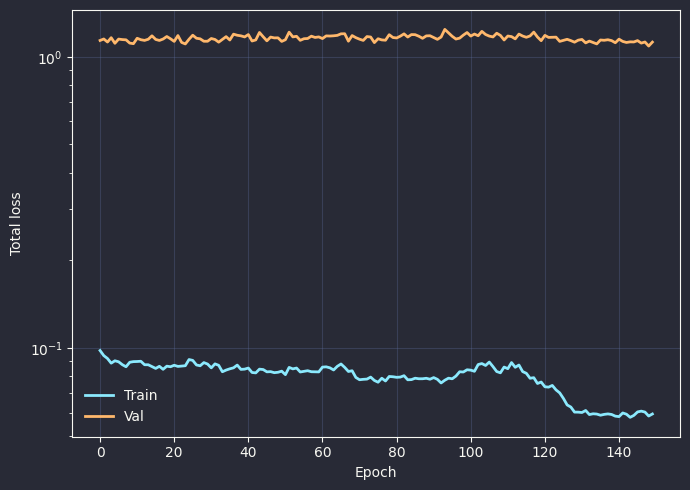

In [29]:
# Balance actual en validación
_, vac = eval_epoch(
    model, val_loader, device,
    alpha=alpha, beta=beta, gamma=gamma, use_amp=use_amp
)
print_loss_balance(vac)

# Loss curves
plt.figure(figsize=(7, 5))
plt.plot(train_hist, label="Train", lw=2)
plt.plot(val_hist, label="Val", lw=2)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Total loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 16. Visualización cualitativa en test

Mostramos ejemplos del test set con:

- input observado
- smooth verdadero y reconstruido
- `Δψ` verdadero y reconstruido
- residuos
- comparación de `(mass, x, y)`

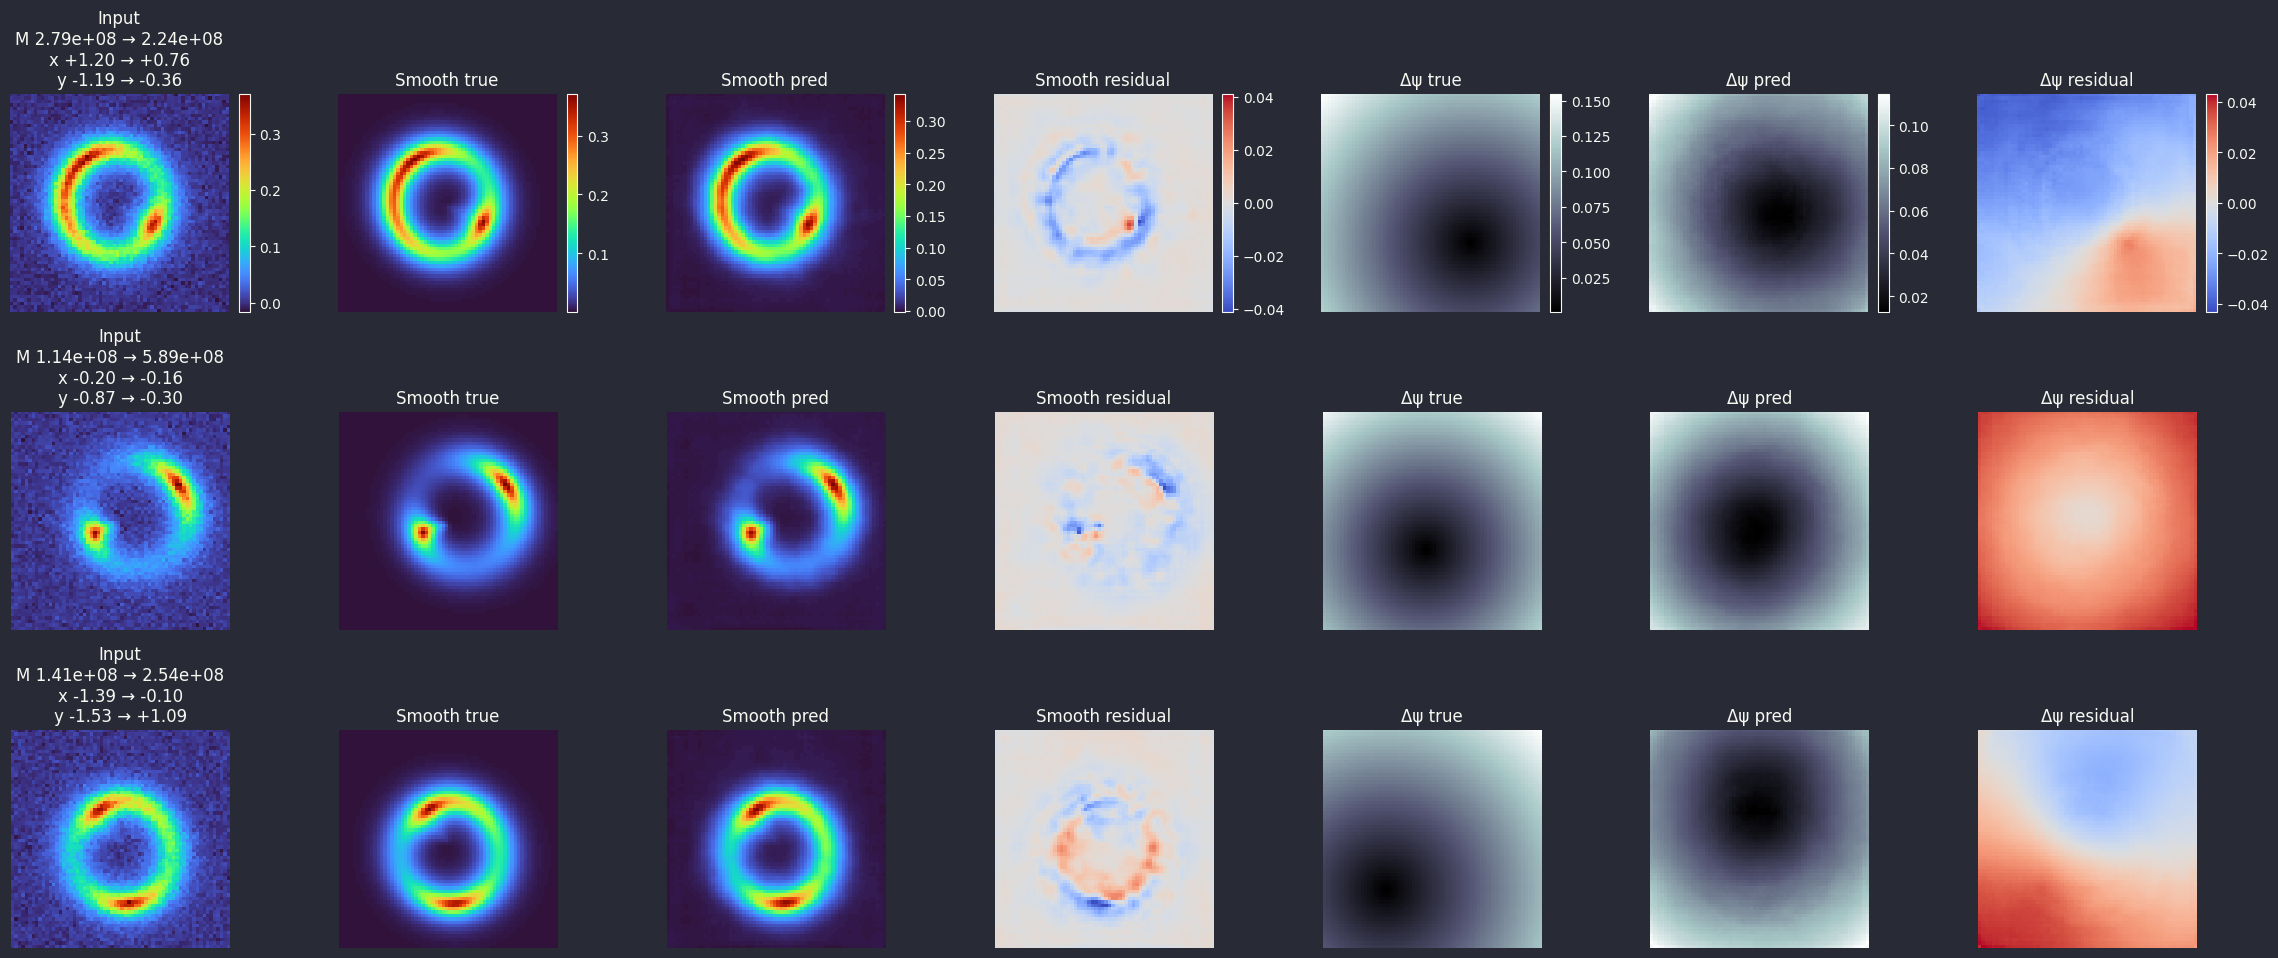

In [22]:
@torch.no_grad()
def visualize_test_batch(model, test_loader, device, nrows=3, seed=123):
    model.eval()

    x, y_true_smooth, y_true_delta, mxy_true = next(iter(test_loader))
    x = x.to(device)
    y_true_smooth = y_true_smooth.to(device)
    y_true_delta  = y_true_delta.to(device)
    mxy_true      = mxy_true.to(device)

    y_pred_smooth, y_pred_delta, mu, logvar, mxy_pred = model(x)

    # to numpy
    x_np        = x.cpu().numpy()
    ys_true_np  = y_true_smooth.cpu().numpy()
    yd_true_np  = y_true_delta.cpu().numpy()
    ys_pred_np  = y_pred_smooth.cpu().numpy()
    yd_pred_np  = y_pred_delta.cpu().numpy()
    mxy_true_np = mxy_true.cpu().numpy()
    mxy_pred_np = mxy_pred.cpu().numpy()

    # denormalize images
    x_den  = x_np       * image_norm_stats["x_std"]  + image_norm_stats["x_mean"]
    ys_t   = ys_true_np * image_norm_stats["y1_std"] + image_norm_stats["y1_mean"]
    ys_p   = ys_pred_np * image_norm_stats["y1_std"] + image_norm_stats["y1_mean"]
    yd_t   = yd_true_np * image_norm_stats["y2_std"] + image_norm_stats["y2_mean"]
    yd_p   = yd_pred_np * image_norm_stats["y2_std"] + image_norm_stats["y2_mean"]

    # denormalize mxy
    mxy_mean_vec = np.array([
        mxy_norm_stats["mass_log10_mean"],
        mxy_norm_stats["x_mean"],
        mxy_norm_stats["y_mean"],
    ])
    mxy_std_vec = np.array([
        mxy_norm_stats["mass_log10_std"],
        mxy_norm_stats["x_std"],
        mxy_norm_stats["y_std"],
    ])

    mxy_true_un = mxy_true_np * mxy_std_vec + mxy_mean_vec
    mxy_pred_un = mxy_pred_np * mxy_std_vec + mxy_mean_vec

    M_true = 10.0 ** mxy_true_un[:, 0]
    X_true = mxy_true_un[:, 1]
    Y_true = mxy_true_un[:, 2]

    M_pred = 10.0 ** mxy_pred_un[:, 0]
    X_pred = mxy_pred_un[:, 1]
    Y_pred = mxy_pred_un[:, 2]

    B = x_den.shape[0]
    nrows = min(nrows, B)
    rng = np.random.default_rng(seed)
    sel = rng.choice(np.arange(B), size=nrows, replace=False)

    fig, axes = plt.subplots(nrows, 7, figsize=(3.3 * 7, 3.2 * nrows))
    if nrows == 1:
        axes = np.expand_dims(axes, 0)

    for r, idx in enumerate(sel):
        inp = x_den[idx, 0]
        s_t = ys_t[idx, 0]
        s_p = ys_p[idx, 0]
        d_t = yd_t[idx, 0]
        d_p = yd_p[idx, 0]

        res_s = s_p - s_t
        res_d = d_p - d_t

        lim_s = max(float(np.max(np.abs(res_s))), 1e-8)
        lim_d = max(float(np.max(np.abs(res_d))), 1e-8)

        # input
        ax = axes[r, 0]
        im = ax.imshow(inp, origin="lower", cmap="turbo")
        ax.set_title(
            f"Input\n"
            f"M {M_true[idx]:.2e} → {M_pred[idx]:.2e}\n"
            f"x {X_true[idx]:+.2f} → {X_pred[idx]:+.2f}\n"
            f"y {Y_true[idx]:+.2f} → {Y_pred[idx]:+.2f}"
        )
        ax.axis("off")
        if r == 0:
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # smooth true
        ax = axes[r, 1]
        im = ax.imshow(s_t, origin="lower", cmap="turbo")
        ax.set_title("Smooth true")
        ax.axis("off")
        if r == 0:
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # smooth pred
        ax = axes[r, 2]
        im = ax.imshow(s_p, origin="lower", cmap="turbo")
        ax.set_title("Smooth pred")
        ax.axis("off")
        if r == 0:
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # residual smooth
        ax = axes[r, 3]
        im = ax.imshow(res_s, origin="lower", cmap="coolwarm", vmin=-lim_s, vmax=lim_s)
        ax.set_title("Smooth residual")
        ax.axis("off")
        if r == 0:
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # delta psi true
        ax = axes[r, 4]
        im = ax.imshow(d_t, origin="lower", cmap="bone")
        ax.set_title("Δψ true")
        ax.axis("off")
        if r == 0:
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # delta psi pred
        ax = axes[r, 5]
        im = ax.imshow(d_p, origin="lower", cmap="bone")
        ax.set_title("Δψ pred")
        ax.axis("off")
        if r == 0:
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # residual delta psi
        ax = axes[r, 6]
        im = ax.imshow(res_d, origin="lower", cmap="coolwarm", vmin=-lim_d, vmax=lim_d)
        ax.set_title("Δψ residual")
        ax.axis("off")
        if r == 0:
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


visualize_test_batch(model, test_loader, device, nrows=3, seed=123)

## 17. Métricas de regresión en test

Evaluamos la calidad de la predicción de:

- `log10(M_sub)`
- `x_sub`
- `y_sub`

y mostramos scatter plots e histogramas de error.

======= Regression metrics =======
[Mass (Msun)] MSE=7.8328e+16  MAE=2.2354e+08  R²=-0.1951
[log10(M)]   MSE=8.3452e-02  MAE=2.3034e-01  R²=-0.1031
[x arcsec]   MSE=1.1803e+00  MAE=9.0819e-01  R²=-0.3846
[y arcsec]   MSE=1.0687e+00  MAE=8.5128e-01  R²=-0.3236


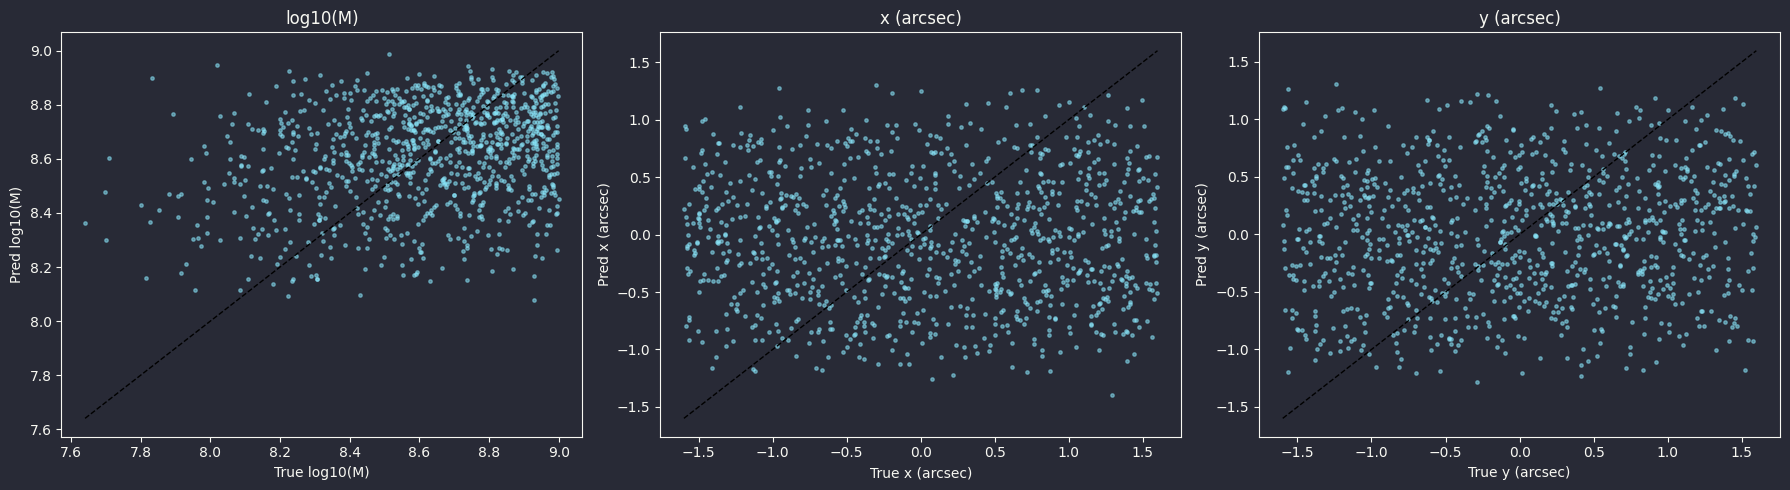

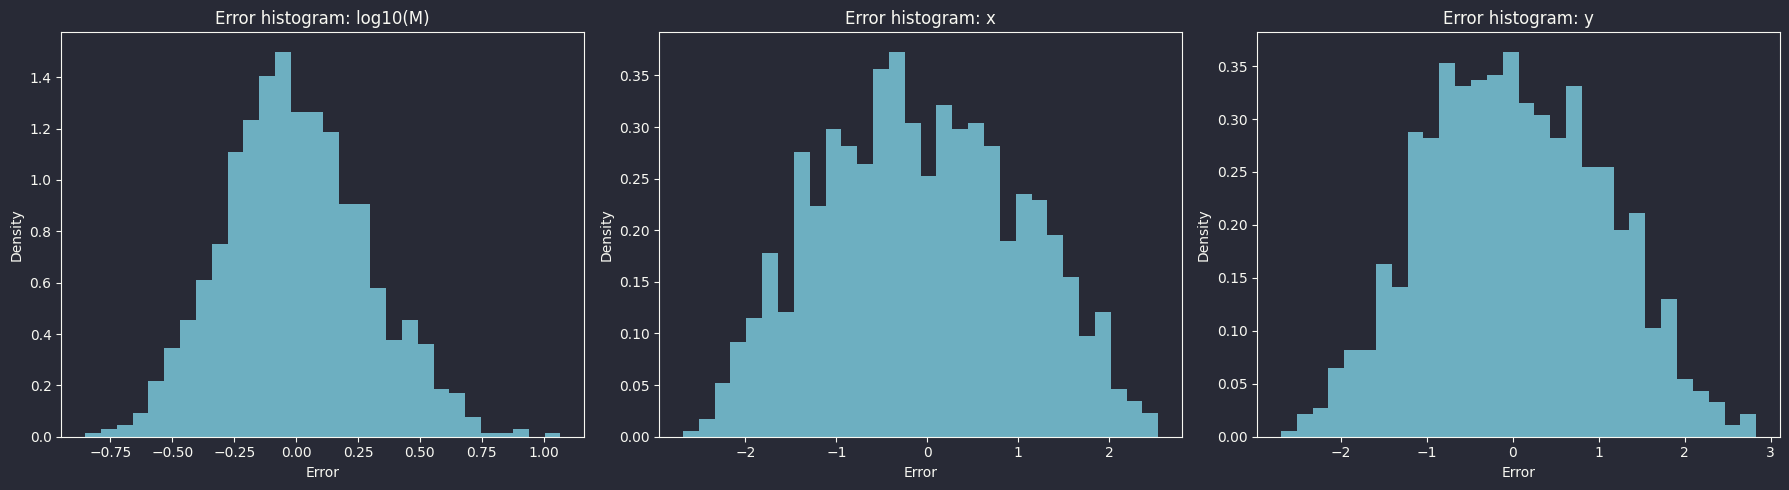

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

@torch.no_grad()
def evaluate_regression_metrics(model, test_loader, device):
    model.eval()

    pred_list, true_list = [], []

    for x, _, _, mxy_true in test_loader:
        x = x.to(device)
        _, _, _, _, mxy_pred = model(x)

        pred_list.append(mxy_pred.detach().cpu().numpy())
        true_list.append(mxy_true.detach().cpu().numpy())

    all_pred_n = np.vstack(pred_list)
    all_true_n = np.vstack(true_list)

    mxy_mean_vec = np.array([
        mxy_norm_stats["mass_log10_mean"],
        mxy_norm_stats["x_mean"],
        mxy_norm_stats["y_mean"],
    ])
    mxy_std_vec = np.array([
        mxy_norm_stats["mass_log10_std"],
        mxy_norm_stats["x_std"],
        mxy_norm_stats["y_std"],
    ])

    all_pred = all_pred_n * mxy_std_vec + mxy_mean_vec
    all_true = all_true_n * mxy_std_vec + mxy_mean_vec

    mass_true_log = all_true[:, 0]
    mass_pred_log = all_pred[:, 0]
    mass_true = 10.0 ** mass_true_log
    mass_pred = 10.0 ** mass_pred_log

    x_true, y_true = all_true[:, 1], all_true[:, 2]
    x_pred, y_pred = all_pred[:, 1], all_pred[:, 2]

    def _metrics(y_t, y_p):
        return (
            mean_squared_error(y_t, y_p),
            mean_absolute_error(y_t, y_p),
            r2_score(y_t, y_p),
        )

    mse_M, mae_M, r2_M = _metrics(mass_true, mass_pred)
    mse_logM, mae_logM, r2_logM = _metrics(mass_true_log, mass_pred_log)
    mse_x, mae_x, r2_x = _metrics(x_true, x_pred)
    mse_y, mae_y, r2_y = _metrics(y_true, y_pred)

    err_logM = mass_pred_log - mass_true_log
    err_x = x_pred - x_true
    err_y = y_pred - y_true

    print("======= Regression metrics =======")
    print("[Mass (Msun)] MSE=%.4e  MAE=%.4e  R²=%.4f" % (mse_M, mae_M, r2_M))
    print("[log10(M)]   MSE=%.4e  MAE=%.4e  R²=%.4f" % (mse_logM, mae_logM, r2_logM))
    print("[x arcsec]   MSE=%.4e  MAE=%.4e  R²=%.4f" % (mse_x, mae_x, r2_x))
    print("[y arcsec]   MSE=%.4e  MAE=%.4e  R²=%.4f" % (mse_y, mae_y, r2_y))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    pairs = [
        (mass_true_log, mass_pred_log, "log10(M)"),
        (x_true, x_pred, "x (arcsec)"),
        (y_true, y_pred, "y (arcsec)"),
    ]
    for ax, (yt, yp, name) in zip(axes, pairs):
        ax.scatter(yt, yp, s=6, alpha=0.5)
        mn = min(yt.min(), yp.min())
        mx = max(yt.max(), yp.max())
        ax.plot([mn, mx], [mn, mx], "k--", lw=1)
        ax.set_xlabel(f"True {name}")
        ax.set_ylabel(f"Pred {name}")
        ax.set_title(name)

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].hist(err_logM, bins=30, density=True, alpha=0.7)
    axes[0].set_title("Error histogram: log10(M)")
    axes[1].hist(err_x, bins=30, density=True, alpha=0.7)
    axes[1].set_title("Error histogram: x")
    axes[2].hist(err_y, bins=30, density=True, alpha=0.7)
    axes[2].set_title("Error histogram: y")

    for ax in axes:
        ax.set_xlabel("Error")
        ax.set_ylabel("Density")

    plt.tight_layout()
    plt.show()

    return {
        "mse_M": mse_M, "mae_M": mae_M, "r2_M": r2_M,
        "mse_logM": mse_logM, "mae_logM": mae_logM, "r2_logM": r2_logM,
        "mse_x": mse_x, "mae_x": mae_x, "r2_x": r2_x,
        "mse_y": mse_y, "mae_y": mae_y, "r2_y": r2_y,
    }

reg_metrics = evaluate_regression_metrics(model, test_loader, device)